# Connect Google Drive



In [23]:
#connect to google drive
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


# Unzip The file

In [24]:
import zipfile
import os

# Path to the zip file in your Google Drive
zip_path = '/content/gdrive/MyDrive/archive.zip'

# Destination folder for unzipped files
unzip_dir = '/content/dataset'
output_path = '/content/preprocessed_dataset'  # Directory for preprocessed images


# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)
os.makedirs(output_path, exist_ok=True)
print("Dataset extracted to:", unzip_dir)


Dataset extracted to: /content/dataset


# Install Necessary libraries

In [31]:
!pip install tensorflow
!pip install numpy
!pip install opencv-python
!pip install tqdm
!pip install matplotlib

In [ ]:
import shutil

# Path to the folder you want to delete
folder_path = '/content/preprocessed_dataset'

# Delete the folder and its contents
shutil.rmtree(folder_path)

print(f"Folder '{folder_path}' has been deleted.")

Folder '/content/preprocessed_dataset' has been deleted.


# Applying Preprocessing techniques on a single image

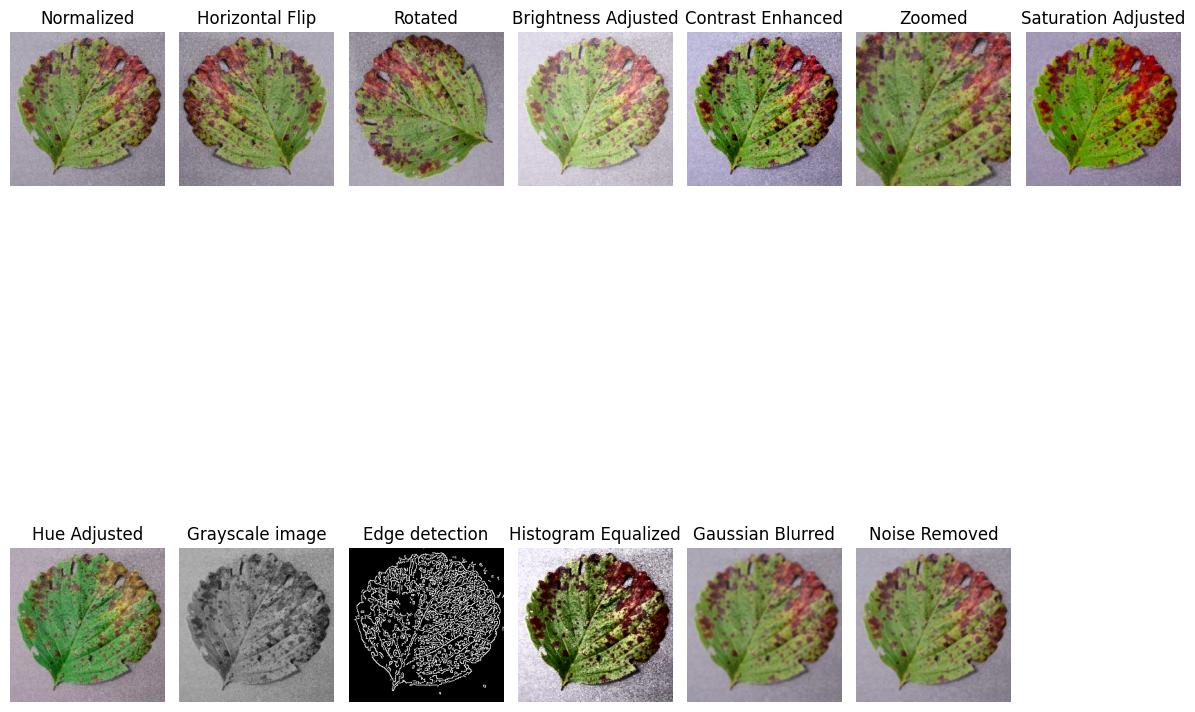

In [45]:
import os
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, gaussian_filter

def preprocess_images(image_path):
    # Load and decode the image
    image = tf.io.read_file('/content/strawberry_scrab_leaf.JPG')
    image = tf.image.decode_image(image, channels=3)

    # Image Resizing
    target_size = (224, 224)
    image = tf.image.resize(image, target_size)

    # Ensure the image is in float32 format
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0, 1]

    processed_images = {}

    # Normalized Image
    processed_images['Normalized'] = image

    # Horizontal Flip
    flipped_img = tf.image.flip_left_right(image)
    processed_images['Horizontal Flip'] = flipped_img

    # Random Rotation
    rotated_img = tf.image.rot90(image, k=1)  # Rotate 90 degrees clockwise
    processed_images['Rotated'] = rotated_img

    # Random Brightness
    brightness_img = tf.image.adjust_brightness(image, delta=0.2)  # Adjust brightness
    processed_images['Brightness Adjusted'] = brightness_img

    # Random Contrast
    contrast_img = tf.image.adjust_contrast(image, contrast_factor=1.5)  # Enhance contrast
    processed_images['Contrast Enhanced'] = contrast_img

    # Random Zoom (cropping and resizing back)
    zoomed_img = tf.image.central_crop(image, central_fraction=0.7)  # Crop 70% of the image
    zoomed_img = tf.image.resize(zoomed_img, target_size)
    processed_images['Zoomed'] = zoomed_img

    # Random Saturation
    saturated_img = tf.image.adjust_saturation(image, saturation_factor=2.0)
    processed_images['Saturation Adjusted'] = saturated_img

    # Random Hue
    hue_img = tf.image.adjust_hue(image, delta=0.1)
    processed_images['Hue Adjusted'] = hue_img

    # GrayScale Image
    image_uint8 = (image.numpy() * 255).astype(np.uint8)
    gray_image_cv2 = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
    gray_image_rgb = cv2.cvtColor(gray_image_cv2, cv2.COLOR_GRAY2RGB)
    gray_image_tf = tf.convert_to_tensor(gray_image_rgb / 255.0)
    processed_images['Grayscale image'] = gray_image_tf
    # gray_image_tf = tf.image.rgb_to_grayscale(image)  # TensorFlow grayscale
    # processed_images['Grayscale image 2'] = gray_image_tf

    # Canny Edge Detection
    img_uint8 = (image.numpy() * 255).astype("uint8")
    edge = cv2.Canny(img_uint8, 100, 200)
    edge_rgb = cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)
    edge_tf = tf.convert_to_tensor(edge_rgb / 255.0)
    processed_images['Edge detection'] = edge_tf

    # Histogram Equalization (YUV)
    img_uint8 = (image.numpy() * 255).astype("uint8")
    img_yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])  # Equalize only Y channel
    img_eq_rgb = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    img_eq_tf = tf.convert_to_tensor(img_eq_rgb, dtype=tf.float32) / 255.0
    processed_images['Histogram Equalized'] = img_eq_tf

    # Gaussian Blur
    blurred_img = cv2.GaussianBlur(img_uint8, (5, 5), 0)  # Kernel size (5, 5)
    blurred_img_tf = tf.convert_to_tensor(blurred_img, dtype=tf.float32) / 255.0
    processed_images['Gaussian Blurred'] = blurred_img_tf

    # Noise Removal: Median Filtering
    median_filtered_img = median_filter(image.numpy(), size=(3, 3, 1))  # Kernel size 3x3
    median_filtered_tf = tf.convert_to_tensor(median_filtered_img, dtype=tf.float32)
    processed_images['Noise Removed'] = median_filtered_tf

    # Visualize all processed images
    plt.figure(figsize=(12, 12))
    for i, (key, img) in enumerate(processed_images.items()):
        plt.subplot(2, 7, i + 1)
        plt.imshow(img)
        plt.title(key)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    return processed_images

image_path = '/content/strawberry_scrab_leaf.JPG'  # Replace with the actual image path
processed_images = preprocess_images(image_path)

# Proprocessing whole dataset

In [47]:
import tensorflow as tf
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

# Function to preprocess a single image
def preprocess_image(image_path, output_path):
    # Load and decode the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)  # Decode as RGB

    # Resize the image
    target_size = (224, 224)
    image = tf.image.resize(image, target_size)

    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Convert to uint8 for OpenCV operations
    img_uint8 = (image.numpy() * 255).astype(np.uint8)

    # Canny Edge Detection
    edge = cv2.Canny(img_uint8, 100, 200)
    edge_rgb = cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)
    edge_tf = tf.convert_to_tensor(edge_rgb / 255.0)

    # Apply Histogram Equalization on the YUV channels
    img_yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])  # Equalize only the Y channel
    hist_eq_image = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # Apply Gaussian Blur
    blurred_image = cv2.GaussianBlur(hist_eq_image, (5, 5), 0)

    # Convert back to TensorFlow tensor for consistency
    final_image_tf = tf.convert_to_tensor(hist_eq_image, dtype=tf.float32) / 255.0

    # Save the preprocessed image
    tf.keras.preprocessing.image.save_img(output_path, final_image_tf.numpy())

    return image.numpy(), final_image_tf.numpy()

# Function to process the entire dataset
def preprocess_dataset(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    all_image_paths = []
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(input_path, input_dir)
                output_path = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                os.makedirs(os.path.dirname(output_path), exist_ok=True)

                # Preprocess the image and save it
                preprocess_image(input_path, output_path)
                all_image_paths.append((input_path, output_path))

    return all_image_paths

# Paths to input and output directories
train_input_dir = '/content/dataset/PlantVillage/train'
val_input_dir = '/content/dataset/PlantVillage/val'
output_dir = '/content/preprocessed_dataset'

# Process the datasets
train_images = preprocess_dataset(train_input_dir, os.path.join(output_dir, 'train'))
val_images = preprocess_dataset(val_input_dir, os.path.join(output_dir, 'val'))

# Combine train and val images for sampling
all_images = train_images + val_images

# Randomly sample 3 images and display original vs preprocessed
sampled_images = random.sample(all_images, 3)
for original_path, preprocessed_path in sampled_images:
    original_image = tf.keras.preprocessing.image.load_img(original_path)
    preprocessed_image = tf.keras.preprocessing.image.load_img(preprocessed_path)

    plt.figure(figsize=(10, 5))

    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')

    # Display preprocessed image
    plt.subplot(1, 2, 2)
    plt.imshow(preprocessed_image)
    plt.title("Preprocessed Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Zip the preprocessed dataset file

In [51]:
import shutil

# Path to the folder to be zipped
folder_to_zip = '/content/preprocessed_dataset'

# Output zip file name
output_zip_file = '/content/preprocessed_dataset.zip'

# Zip the folder
shutil.make_archive('/content/preprocessed_dataset', 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' successfully zipped to '{output_zip_file}'")


Folder '/content/preprocessed_dataset' successfully zipped to '/content/preprocessed_dataset.zip'
